In [1]:
# Veri setini Kaggle'dan notebook içersine aktaralım.
# !pip install kaggle
# Veri Seti: https://www.kaggle.com/datasets/puneet6060/intel-image-classification

In [2]:
import os
from google.colab import userdata

kaggle_api_key = userdata.get("KAGGLE_API_KEY")
kaggle_username = userdata.get("KAGGLE_USERNAME")

In [3]:
kaggle_username

'ensarakbas'

In [4]:
KAGGLE_USERNAME = kaggle_username
KAGGLE_API_KEY = kaggle_api_key

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_API_KEY")

In [5]:
# Veri setini indir
!kaggle datasets download puneet6060/intel-image-classification

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:16<00:00, 21.8MB/s]



In [ ]:
# Zip dosyasını aç
!unzip intel-image-classification.zip

In [7]:
!ls

intel-image-classification.zip	sample_data  seg_pred  seg_test  seg_train


In [8]:
train_dir = "seg_train"
test_dir = "seg_test"

In [9]:
# Eğitim ve test dizinlerindeki sınıfları kontrol edelim
if os.path.exists(train_dir):
    print(f"Eğitim klasöründeki sınıflar: {os.listdir(train_dir + '/seg_train')}")
if os.path.exists(test_dir):
    print(f"Test klasöründeki sınıflar: {os.listdir(test_dir + '/seg_test')}")

Eğitim klasöründeki sınıflar: ['forest', 'street', 'glacier', 'mountain', 'sea', 'buildings']
Test klasöründeki sınıflar: ['forest', 'street', 'glacier', 'mountain', 'sea', 'buildings']


In [10]:
train_path = 'seg_train/seg_train'
test_path = 'seg_test/seg_test'
pred_path = 'seg_pred/seg_pred'

print("Güncel Eğitim Dizini İçeriği:", os.listdir(train_path))
print("Güncel Test Dizini İçeriği:", os.listdir(test_path))

Güncel Eğitim Dizini İçeriği: ['forest', 'street', 'glacier', 'mountain', 'sea', 'buildings']
Güncel Test Dizini İçeriği: ['forest', 'street', 'glacier', 'mountain', 'sea', 'buildings']


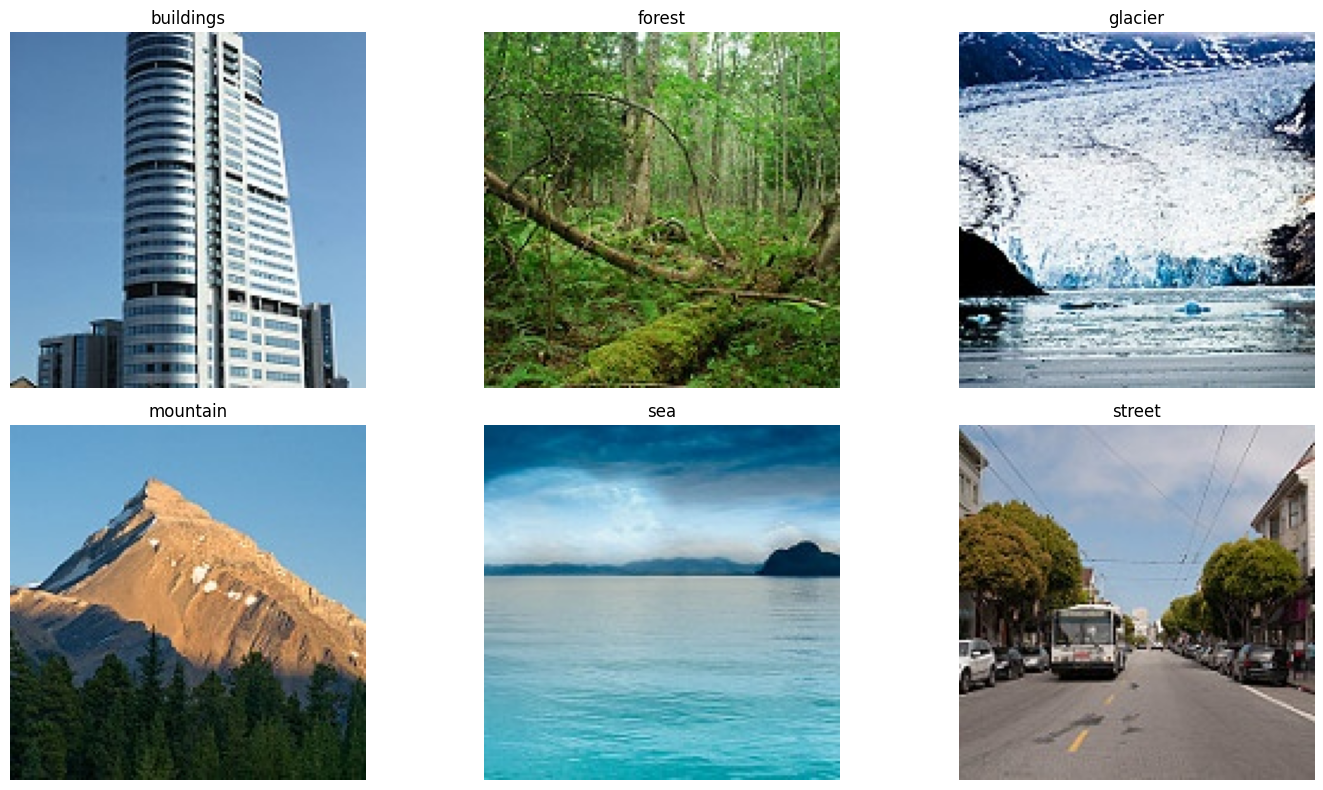

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def show_random_images(target_dir):
    plt.figure(figsize=(15, 8))
    classes = sorted(os.listdir(target_dir))

    for i, class_name in enumerate(classes):
        class_path = os.path.join(target_dir, class_name)
        if not os.path.isdir(class_path): continue

        image_name = random.choice(os.listdir(class_path))
        image_path = os.path.join(class_path, image_name)

        img = mpimg.imread(image_path)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(train_path)

In [12]:
def count_images(target_dir):
    for class_name in sorted(os.listdir(target_dir)):
        class_path = os.path.join(target_dir, class_name)
        if os.path.isdir(class_path):
            n_images = len(os.listdir(class_path))
            print(f"{class_name:10}: {n_images} görsel")

print("Eğitim Seti Dağılımı (Train):")
count_images(train_path)
print("\nTest Seti Dağılımı (Test):")
count_images(test_path)

Eğitim Seti Dağılımı (Train):
buildings : 2191 görsel
forest    : 2271 görsel
glacier   : 2404 görsel
mountain  : 2512 görsel
sea       : 2274 görsel
street    : 2382 görsel

Test Seti Dağılımı (Test):
buildings : 437 görsel
forest    : 474 görsel
glacier   : 553 görsel
mountain  : 525 görsel
sea       : 510 görsel
street    : 501 görsel


In [13]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [14]:
weigths = torchvision.models.ResNet50_Weights.DEFAULT
model = torchvision.models.resnet50(weights=weigths)

weigths

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


ResNet50_Weights.IMAGENET1K_V2

In [15]:
model_transforms = weigths.transforms()
model_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [16]:
NUM_WORKERS = os.cpu_count()


def create_dataloaders(
        train_dir: str,
        test_dir: str,
        transform: transforms.Compose,
        batch_size: int,
        num_workers: int = NUM_WORKERS,
):
    train_data = datasets.ImageFolder(
        root=train_dir,
        transform=transform,
        target_transform=None)

    test_data = datasets.ImageFolder(
        root=test_dir,
        transform=transform)

    class_names = train_data.classes

    train_dataloader = DataLoader(dataset=train_data,
                                  batch_size=batch_size,
                                  num_workers=num_workers,
                                  shuffle=True)

    test_dataloader = DataLoader(dataset=test_data,
                                 batch_size=batch_size,
                                 num_workers=num_workers,
                                 shuffle=False)

    return train_dataloader, test_dataloader, class_names

In [17]:
train_dataloader, test_dataloader, class_names = create_dataloaders(
    train_dir=train_path,
    test_dir=test_path,
    transform=model_transforms,
    batch_size=32
)

In [18]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("GPU var mı ?", torch.cuda.is_available())
print(f"Device: {device}")
print("Device Name:", torch.cuda.get_device_name(0))

GPU var mı ? True
Device: cuda
Device Name: Tesla T4


In [19]:
model = torchvision.models.resnet50(weights=weigths).to(device)

In [20]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
!pip install torchinfo

In [22]:
from torchinfo import summary

summary(model=model,
        input_size=(1, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ResNet                                   [1, 3, 224, 224]          [1, 1000]                 --                        True
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         9,408                     True
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         128                       True
├─ReLU: 1-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --                        --
├─MaxPool2d: 1-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           --                        --
├─Sequential: 1-5                        [1, 64, 56, 56]           [1, 256, 56, 56]          --                        True
│    └─Bottleneck: 2-1                   [1, 64, 56, 56]           [1, 256, 56, 56]          --                        True
│    │ 

In [23]:
# Modelin tüm parametrelerini donduruyoruz (freeze)
# Bu sayede eğitim sırasında önceden eğitilmiş (pretrained) ağırlıklar güncellenmez.
for param in model.parameters():
    param.requires_grad = False

In [24]:
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [30]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# ResNet50'de son katman adı 'fc'dir.
# class_names uzunluğunu (6) çıkış katmanı olarak ayarlıyoruz.
output_shape = len(class_names)

model.fc = torch.nn.Sequential(
    torch.nn.Linear(in_features=2048,
                    out_features=output_shape,
                    bias=True)).to(device)

In [31]:
summary(model=model,
        input_size=(32, 3, 224, 224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
ResNet (ResNet)                          [32, 3, 224, 224]    [32, 6]              12,294               Partial
├─Conv2d (conv1)                         [32, 3, 224, 224]    [32, 64, 112, 112]   (9,408)              False
├─BatchNorm2d (bn1)                      [32, 64, 112, 112]   [32, 64, 112, 112]   (128)                False
├─ReLU (relu)                            [32, 64, 112, 112]   [32, 64, 112, 112]   --                   --
├─MaxPool2d (maxpool)                    [32, 64, 112, 112]   [32, 64, 56, 56]     --                   --
├─Sequential (layer1)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   False
│    └─Bottleneck (0)                    [32, 64, 56, 56]     [32, 256, 56, 56]    --                   False
│    │    └─Conv2d (conv1)               [32, 64, 56, 56]     [32, 64, 56, 56]     (4,096)              False
│    │    

In [32]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [33]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Modeli eğitim moduna alıyoruz
    model.train()

    # Train loss ve train accuracy değerlerini başlatıyoruz
    train_loss, train_acc = 0, 0

    # DataLoader içindeki batch'ler üzerinde döngü kuruyoruz
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Loss değerini hesapla ve toplam train loss'a ekle
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer gradientlerini sıfırla
        optimizer.zero_grad()

        # 4. Backpropagation işlemini yap
        loss.backward()

        # 5. Optimizer ile model parametrelerini güncelle
        optimizer.step()

        # Batch bazında accuracy hesapla ve toplam train accuracy değerine ekle
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Ortalama train loss ve train accuracy değerlerini hesapla
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)

    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Modeli değerlendirme moduna alıyoruz
    model.eval()

    # Test loss ve test accuracy değerlerini başlatıyoruz
    test_loss, test_acc = 0, 0

    # Test aşamasında gradient hesaplamaya gerek yoktur
    with torch.inference_mode():

        # DataLoader içindeki batch'ler üzerinde döngü kuruyoruz
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Loss değerini hesapla ve toplam test loss'a ekle
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Batch bazında accuracy hesapla ve toplam test accuracy değerine ekle
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Ortalama test loss ve test accuracy değerlerini hesapla
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)

    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # Sonuçları saklamak için boş bir dictionary oluşturuyoruz
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # Belirlenen epoch sayısı kadar eğitim ve test adımlarını çalıştırıyoruz
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # Eğitim sürecinde neler olduğunu ekrana yazdırıyoruz
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # Sonuçları dictionary içine ekliyoruz
        # Eğer değer tensor formatındaysa CPU'ya alıp float değere çeviriyoruz
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # Epoch'lar bittikten sonra tüm sonuçları döndürüyoruz
    return results

In [34]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Şimdi eğitimi tekrar başlatalım
results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                epochs=5,
                device=device)

Epoch: 1 | train_loss: 0.4484 | train_acc: 0.8659 | test_loss: 0.2854 | test_acc: 0.9039
Epoch: 2 | train_loss: 0.2729 | train_acc: 0.9069 | test_loss: 0.2519 | test_acc: 0.9141
Epoch: 3 | train_loss: 0.2439 | train_acc: 0.9145 | test_loss: 0.2353 | test_acc: 0.9148
Epoch: 4 | train_loss: 0.2201 | train_acc: 0.9227 | test_loss: 0.2358 | test_acc: 0.9108
Epoch: 5 | train_loss: 0.2083 | train_acc: 0.9258 | test_loss: 0.2231 | test_acc: 0.9158


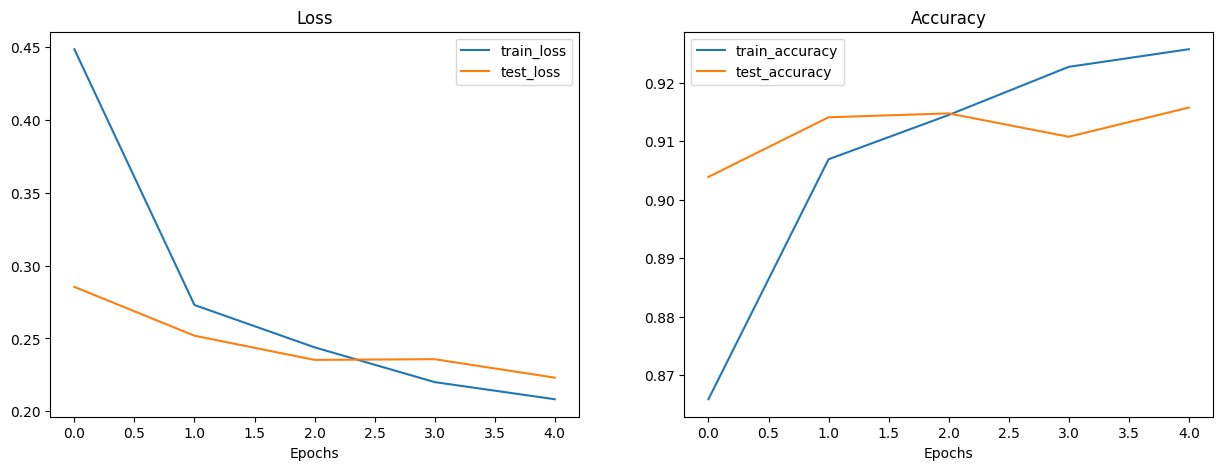

In [36]:
def plot_loss_curves(results):
    loss = results['train_loss']
    test_loss = results['test_loss']
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']
    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 5))

    # Loss Grafiği
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Accuracy Grafiği
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()

plot_loss_curves(results)

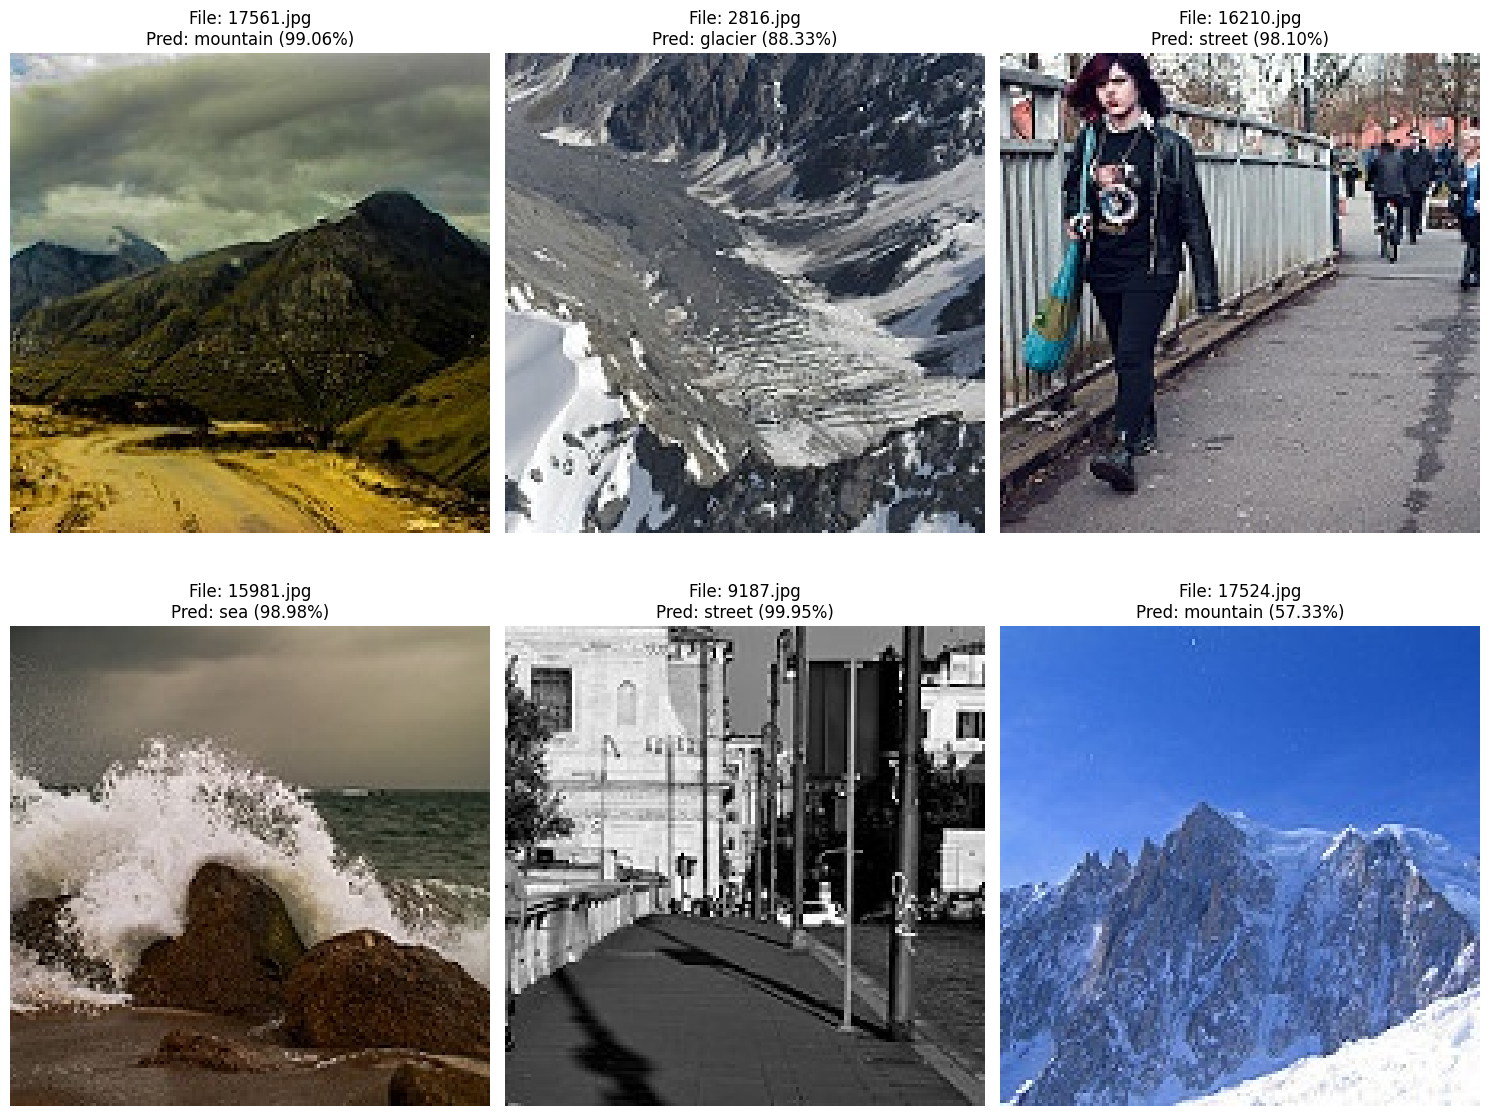

In [38]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def transform_predict(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])

    model.eval()
    with torch.inference_mode():
      transformed_image = image_transform(img).unsqueeze(dim=0)
      target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    return img, class_names[target_image_pred_label], target_image_pred_probs.max()

# Rastgele 6 görsel seçelim ve tahmin edelim
pred_image_list = os.listdir(pred_path)
random_images = random.sample(pred_image_list, 6)

plt.figure(figsize=(15, 12))

for i, image_name in enumerate(random_images):
    image_path = os.path.join(pred_path, image_name)
    img, pred_label, prob = transform_predict(model=model,
                                              image_path=image_path,
                                              class_names=class_names,
                                              transform=model_transforms)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)

    plt.title(f"File: {image_name}\nPred: {pred_label} ({prob:.2%})")
    plt.axis(False)

plt.tight_layout()
plt.show()